In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/youtube_channel_real_performance_analytics.csv')
df

,ID,Video Duration,Video Publish Time,Days Since Publish,Day,Month,Year,Day of Week,Revenue per 1000 Views (USD),Monetized Playbacks (Estimate),...,Watched (Not Skipped) (%),Feed Impressions,Average View Percentage (%),Average View Duration,Views,Watch Time (hours),Subscribers,Estimated Revenue (USD),Impressions,Video Thumbnail CTR (%)
0,0,201.0,2016-06-02 00:00:00,0,2,6,2016,Thursday,0.024,723.0,...,0.0,0.0,40.38,81.0,23531.0,533.1636,51.0,0.561,41118.0,27.66
1,1,391.0,2016-06-10 00:00:00,8,10,6,2016,Friday,0.056,727.0,...,0.0,0.0,39.85,156.0,11478.0,500.5628,33.0,0.648,41627.0,5.85
2,2,133.0,2016-06-14 00:00:00,4,14,6,2016,Tuesday,0.014,76.0,...,0.0,0.0,30.88,41.0,6153.0,70.7287,8.0,0.089,38713.0,7.07
3,3,14.0,2016-06-29 00:00:00,15,29,6,2016,Wednesday,0.004,18.0,...,0.0,0.0,103.05,14.0,4398.0,17.6251,2.0,0.017,35245.0,5.60
4,4,45.0,2016-07-01 00:00:00,2,1,7,2016,Friday,0.000,0.0,...,0.0,0.0,55.70,25.0,14659.0,104.3341,28.0,0.000,46218.0,8.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,359,779.0,2024-08-25 00:00:00,10,25,8,2024,Sunday,0.806,4104.0,...,0.0,0.0,50.82,396.0,10018.0,1104.5703,16.0,8.063,97065.0,8.23
360,360,818.0,2024-09-01 00:00:00,7,1,9,2024,Sunday,1.050,3273.0,...,0.0,0.0,42.05,344.0,8298.0,793.6508,7.0,8.705,65912.0,9.36
361,361,2233.0,2024-09-16 00:00:00,15,16,9,2024,Monday,1.161,3605.0,...,0.0,0.0,31.48,703.0,8487.0,1657.8232,14.0,9.852,76517.0,8.28
362,362,391.0,2024-09-25 00:00:00,9,25,9,2024,Wednesday,0.547,2338.0,...,0.0,0.0,62.38,244.0,7060.0,479.5583,11.0,3.858,67091.0,8.29


Exploratory Data Analysis

In [3]:
df.isnull().sum()

,0
ID,0
Video Duration,0
Video Publish Time,0
Days Since Publish,0
Day,0
...,...
Watch Time (hours),0
Subscribers,0
Estimated Revenue (USD),0
Impressions,0


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 70 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   ID                                  364 non-null    int64  
 1   Video Duration                      364 non-null    float64
 2   Video Publish Time                  364 non-null    object 
 3   Days Since Publish                  364 non-null    int64  
 4   Day                                 364 non-null    int64  
 5   Month                               364 non-null    int64  
 6   Year                                364 non-null    int64  
 7   Day of Week                         364 non-null    object 
 8   Revenue per 1000 Views (USD)        364 non-null    float64
 9   Monetized Playbacks (Estimate)      364 non-null    float64
 10  Playback-Based CPM (USD)            364 non-null    float64
 11  CPM (USD)                           364 non-n

In [6]:
df.describe()

,ID,Video Duration,Days Since Publish,Day,Month,Year,Revenue per 1000 Views (USD),Monetized Playbacks (Estimate),Playback-Based CPM (USD),CPM (USD),...,Watched (Not Skipped) (%),Feed Impressions,Average View Percentage (%),Average View Duration,Views,Watch Time (hours),Subscribers,Estimated Revenue (USD),Impressions,Video Thumbnail CTR (%)
count,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,...,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,3.640000e+02,364.000000
mean,181.500000,664.239011,8.406593,15.807692,6.642857,2018.736264,0.112283,8934.711538,1.553734,1.059005,...,0.824176,0.008242,45.970989,285.612637,128800.101648,10058.965455,321.024725,8.852052,9.595286e+05,7.914615
std,105.221988,330.646183,15.371239,8.924004,3.421521,2.530629,0.179668,12967.843236,1.078549,0.728380,...,9.053369,0.090534,12.457470,116.595678,118209.844270,9516.160361,444.594763,13.414650,1.180519e+06,2.903383
min,0.000000,9.000000,0.000000,1.000000,1.000000,2016.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,15.050000,8.000000,2461.000000,12.697900,-3.000000,0.000000,3.222800e+04,0.620000
25%,90.750000,496.000000,3.000000,8.000000,4.000000,2017.000000,0.015000,349.500000,0.817750,0.522000,...,0.000000,0.000000,40.252500,233.750000,27160.500000,2759.404250,41.000000,0.443250,1.317082e+05,6.420000
50%,181.500000,613.000000,5.000000,16.000000,7.000000,2018.000000,0.050000,3564.000000,1.540500,1.155500,...,0.000000,0.000000,45.465000,286.500000,101950.500000,8102.962950,180.000000,4.285000,6.204065e+05,8.395000
75%,272.250000,786.500000,9.000000,23.000000,10.000000,2021.000000,0.143500,13579.250000,2.025250,1.458750,...,0.000000,0.000000,51.010000,344.250000,198169.500000,14084.498550,421.250000,11.476250,1.368464e+06,9.920000
max,363.000000,2311.000000,260.000000,31.000000,12.000000,2024.000000,1.600000,100566.000000,7.385000,6.295000,...,100.000000,1.000000,117.300000,776.000000,670990.000000,53794.658700,3728.000000,103.117000,1.270226e+07,27.660000


In [7]:
df.head()

,ID,Video Duration,Video Publish Time,Days Since Publish,Day,Month,Year,Day of Week,Revenue per 1000 Views (USD),Monetized Playbacks (Estimate),...,Watched (Not Skipped) (%),Feed Impressions,Average View Percentage (%),Average View Duration,Views,Watch Time (hours),Subscribers,Estimated Revenue (USD),Impressions,Video Thumbnail CTR (%)
0,0,201.0,2016-06-02 00:00:00,0,2,6,2016,Thursday,0.024,723.0,...,0.0,0.0,40.38,81.0,23531.0,533.1636,51.0,0.561,41118.0,27.66
1,1,391.0,2016-06-10 00:00:00,8,10,6,2016,Friday,0.056,727.0,...,0.0,0.0,39.85,156.0,11478.0,500.5628,33.0,0.648,41627.0,5.85
2,2,133.0,2016-06-14 00:00:00,4,14,6,2016,Tuesday,0.014,76.0,...,0.0,0.0,30.88,41.0,6153.0,70.7287,8.0,0.089,38713.0,7.07
3,3,14.0,2016-06-29 00:00:00,15,29,6,2016,Wednesday,0.004,18.0,...,0.0,0.0,103.05,14.0,4398.0,17.6251,2.0,0.017,35245.0,5.60
4,4,45.0,2016-07-01 00:00:00,2,1,7,2016,Friday,0.000,0.0,...,0.0,0.0,55.70,25.0,14659.0,104.3341,28.0,0.000,46218.0,8.62


In [8]:
df.columns

Index(['ID', 'Video Duration', 'Video Publish Time', 'Days Since Publish',
       'Day', 'Month', 'Year', 'Day of Week', 'Revenue per 1000 Views (USD)',
       'Monetized Playbacks (Estimate)', 'Playback-Based CPM (USD)',
       'CPM (USD)', 'Ad Impressions', 'Estimated AdSense Revenue (USD)',
       'DoubleClick Revenue (USD)', 'YouTube Ads Revenue (USD)',
       'Watch Page Ads Revenue (USD)', 'YouTube Premium (USD)',
       'Transaction Revenue (USD)', 'Transactions',
       'Revenue from Transactions (USD)', 'Reactions', 'Chat Messages Count',
       'Reminders Set', 'Stream Hours', 'Remix Views', 'Remix Count',
       'Subscribers from Posts', 'New Comments', 'Shares', 'Like Rate (%)',
       'Dislikes', 'Likes', 'Unsubscribes', 'New Subscribers',
       'Returned Items (USD)', 'Unconfirmed Commissions (USD)',
       'Approved Commissions (USD)', 'Orders', 'Total Sales Volume (USD)',
       'End Screen Click-Through Rate (%)', 'End Screen Impressions',
       'End Screen Clicks', 

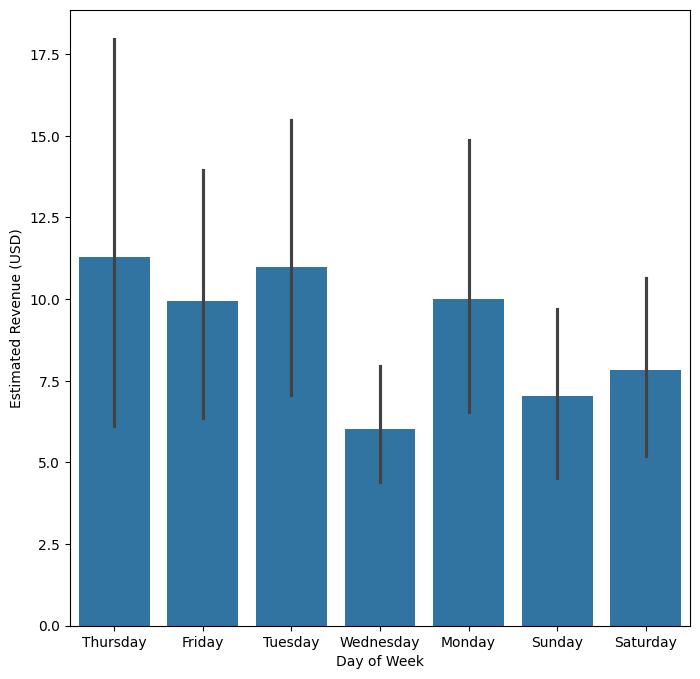

In [9]:
plt.figure(figsize=(8,8))
sns.barplot(x='Day of Week',y='Estimated Revenue (USD)',data = df)
plt.show()

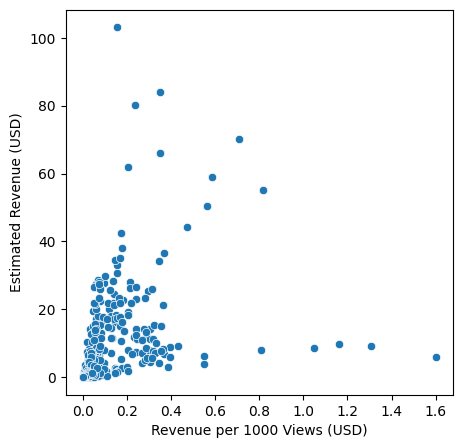

In [10]:
plt.figure(figsize=(5,5))
sns.scatterplot(x='Revenue per 1000 Views (USD)',y='Estimated Revenue (USD)',data=df)
plt.show()

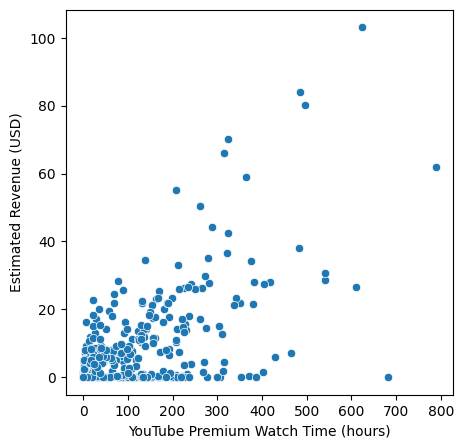

In [11]:
plt.figure(figsize=(5,5))
sns.scatterplot(x='YouTube Premium Watch Time (hours)',y='Estimated Revenue (USD)',data=df)
plt.show()

selecting top 15 features to reduce dimensinality

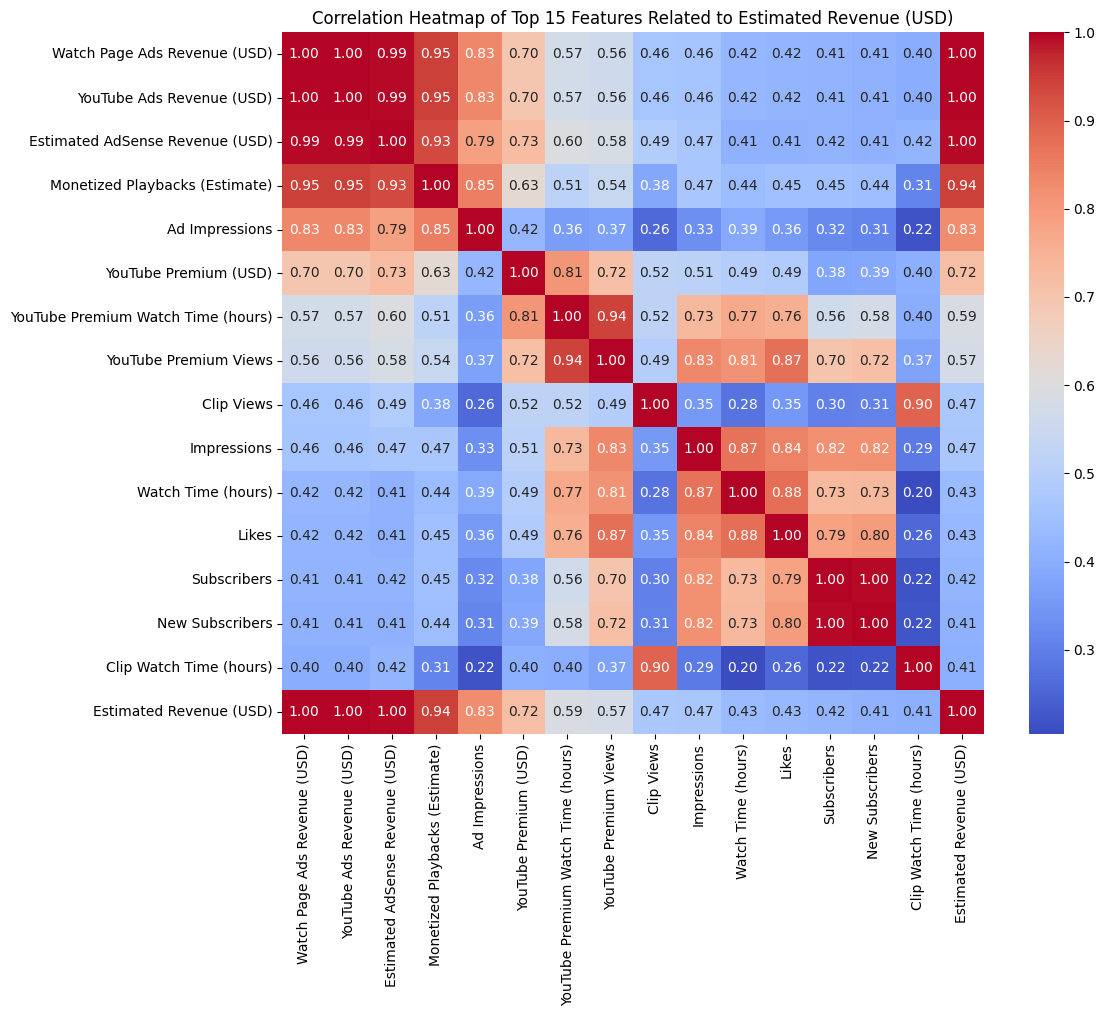

In [12]:
correlation_matrix = df.corr(numeric_only=True)
target_corr = correlation_matrix["Estimated Revenue (USD)"].drop("Estimated Revenue (USD)")
top_corr_features = target_corr.abs().sort_values(ascending=False).head(15)

# Get the list of top 15 features plus the target
top_features = top_corr_features.index.tolist() + ["Estimated Revenue (USD)"]
corr_subset = df[top_features].corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_subset, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap of Top 15 Features Related to Estimated Revenue (USD)")
plt.tight_layout()
plt.show()

In [13]:
# Get all column names
all_columns = set(df.columns)

# Your top 15 correlated features + target
top_15_features = [
    'Watch Page Ads Revenue (USD)', 'YouTube Ads Revenue (USD)',
    'Estimated AdSense Revenue (USD)', 'Monetized Playbacks (Estimate)',
    'Ad Impressions', 'YouTube Premium (USD)', 'YouTube Premium Watch Time (hours)',
    'YouTube Premium Views', 'Clip Views', 'Impressions',
    'Watch Time (hours)', 'Likes', 'Subscribers',
    'New Subscribers', 'Clip Watch Time (hours)',
    'Estimated Revenue (USD)'
]

# Get columns that are not in the top 15 set
remaining_columns = all_columns - set(top_15_features)

# Print remaining columns
print(list(remaining_columns))


['Returned Items (USD)', 'Card Click-Through Rate (%)', 'Playlist Watch Time (hours)', 'Orders', 'End Screen Impressions', 'Revenue from Transactions (USD)', 'Card Clicks', 'Watched (Not Skipped) (%)', 'Unconfirmed Commissions (USD)', 'Average Views per User', 'Stream Hours', 'Average View Percentage (%)', 'Video Thumbnail CTR (%)', 'End Screen Clicks', 'Views per Playlist Start', 'Playback-Based CPM (USD)', 'Day', 'Approved Commissions (USD)', 'Reminders Set', 'Teaser Click-Through Rate (%)', 'Teaser Impressions', 'New Comments', 'Remix Count', 'Video Duration', 'Remix Views', 'Video Publish Time', 'Days Since Publish', 'Teaser Clicks', 'Playlist Views', 'Year', 'Chat Messages Count', 'Total Sales Volume (USD)', 'New Viewers', 'Card Impressions', 'Month', 'Transaction Revenue (USD)', 'Dislikes', 'Revenue per 1000 Views (USD)', 'Like Rate (%)', 'Average View Duration', 'Returning Viewers', 'Unique Viewers', 'Unsubscribes', 'End Screen Click-Through Rate (%)', 'ID', 'Transactions', 'Sha

In [14]:
# Define the list of top 15 features + target
top_15_features = [
    'Watch Page Ads Revenue (USD)', 'YouTube Ads Revenue (USD)',
    'Estimated AdSense Revenue (USD)', 'Monetized Playbacks (Estimate)',
    'Ad Impressions', 'YouTube Premium (USD)', 'YouTube Premium Watch Time (hours)',
    'YouTube Premium Views', 'Clip Views', 'Impressions',
    'Watch Time (hours)', 'Likes', 'Subscribers',
    'New Subscribers', 'Clip Watch Time (hours)',
    'Estimated Revenue (USD)'
]

# Drop all other columns not in the top 15 list
df = df[top_15_features]

# Verify the result
print(df.columns)


Index(['Watch Page Ads Revenue (USD)', 'YouTube Ads Revenue (USD)',
       'Estimated AdSense Revenue (USD)', 'Monetized Playbacks (Estimate)',
       'Ad Impressions', 'YouTube Premium (USD)',
       'YouTube Premium Watch Time (hours)', 'YouTube Premium Views',
       'Clip Views', 'Impressions', 'Watch Time (hours)', 'Likes',
       'Subscribers', 'New Subscribers', 'Clip Watch Time (hours)',
       'Estimated Revenue (USD)'],
      dtype='object')


In [15]:
df.head()

,Watch Page Ads Revenue (USD),YouTube Ads Revenue (USD),Estimated AdSense Revenue (USD),Monetized Playbacks (Estimate),Ad Impressions,YouTube Premium (USD),YouTube Premium Watch Time (hours),YouTube Premium Views,Clip Views,Impressions,Watch Time (hours),Likes,Subscribers,New Subscribers,Clip Watch Time (hours),Estimated Revenue (USD)
0,0.551,1.002,0.527,723.0,981.0,0.010,2.5358,152.0,10.0,41118.0,533.1636,924.0,51.0,54.0,0.1575,0.561
1,0.645,1.172,0.635,727.0,861.0,0.004,0.8911,32.0,0.0,41627.0,500.5628,322.0,33.0,34.0,0.0000,0.648
2,0.088,0.160,0.088,76.0,88.0,0.001,0.1838,28.0,0.0,38713.0,70.7287,239.0,8.0,8.0,0.0000,0.089
3,0.016,0.030,0.016,18.0,35.0,0.000,0.0711,20.0,0.0,35245.0,17.6251,220.0,2.0,2.0,0.0000,0.017
4,0.000,0.000,0.000,0.0,0.0,0.000,0.2519,39.0,0.0,46218.0,104.3341,602.0,28.0,31.0,0.0000,0.000


Watch Page Ads Revenue (USD)


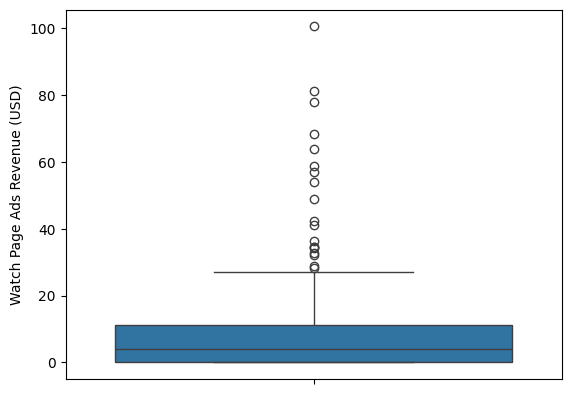

YouTube Ads Revenue (USD)


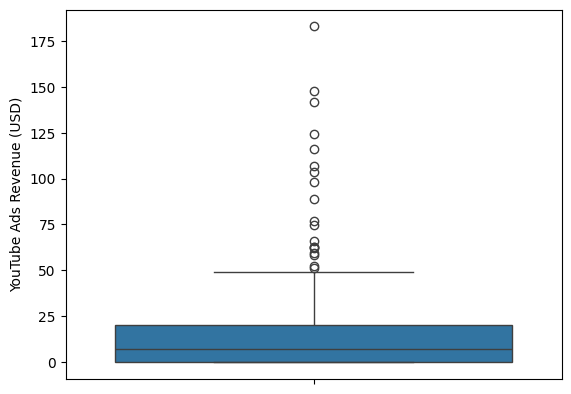

Estimated AdSense Revenue (USD)


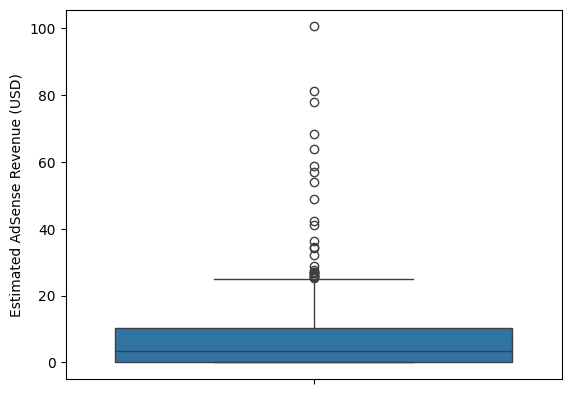

Monetized Playbacks (Estimate)


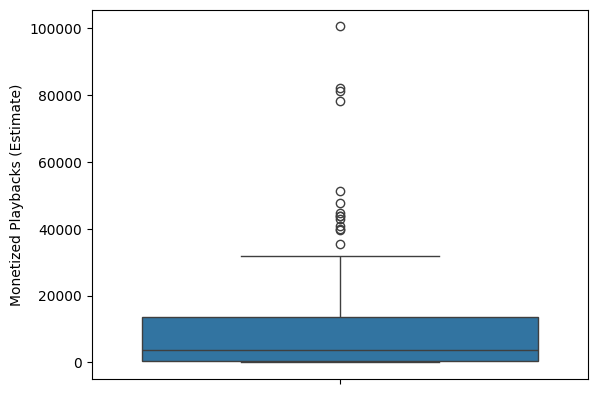

Ad Impressions


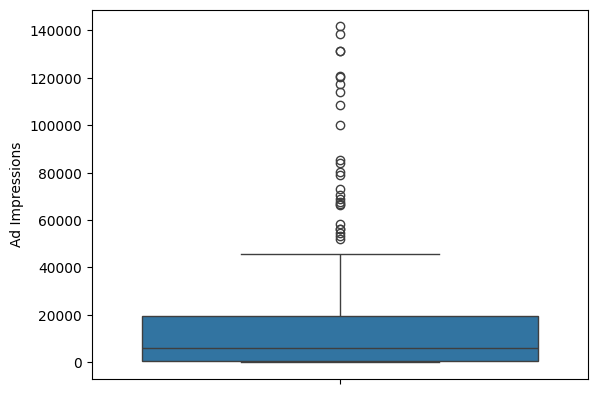

YouTube Premium (USD)


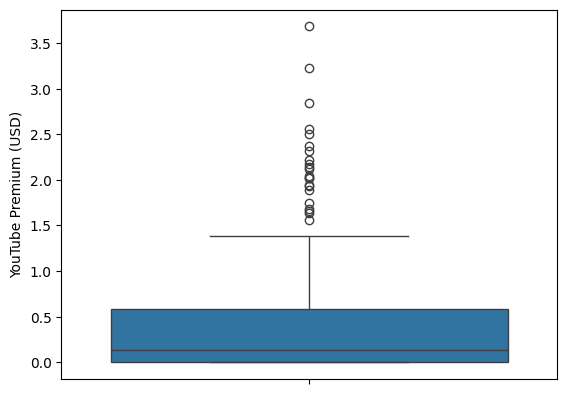

YouTube Premium Watch Time (hours)


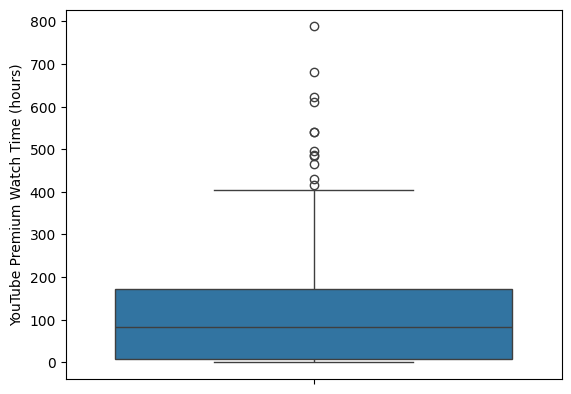

YouTube Premium Views


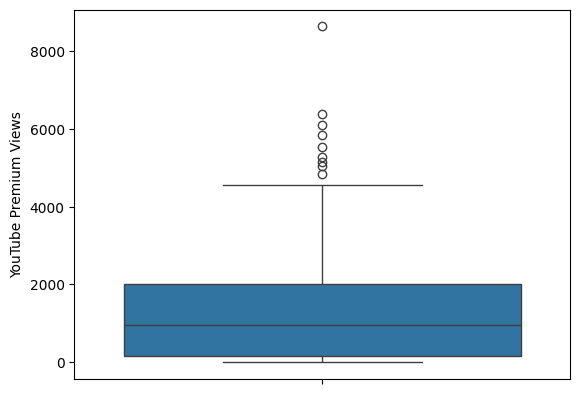

Clip Views


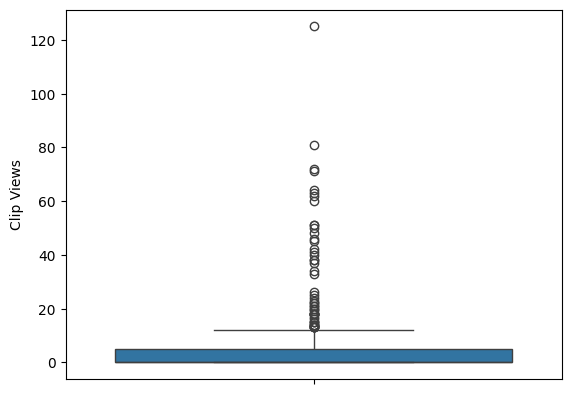

Impressions


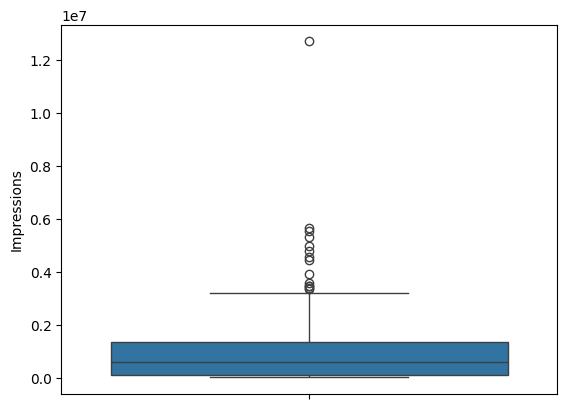

Watch Time (hours)


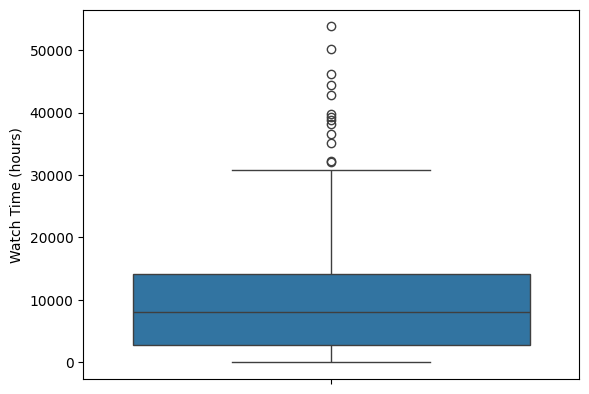

Likes


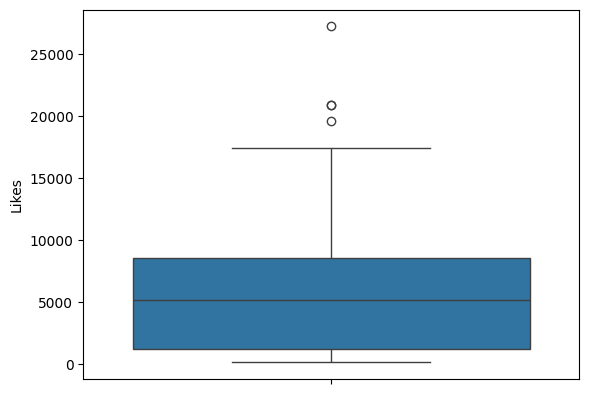

Subscribers


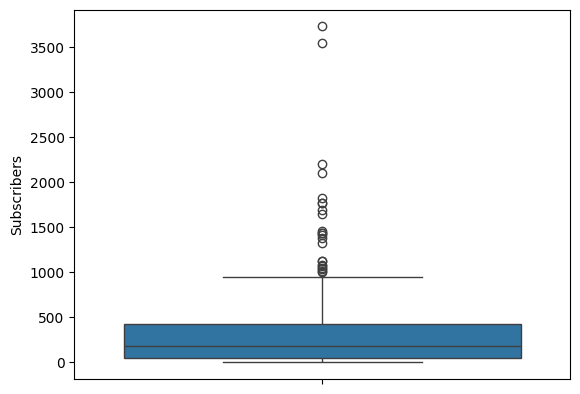

New Subscribers


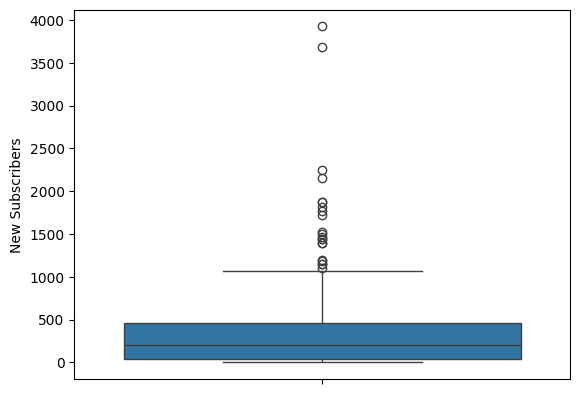

Clip Watch Time (hours)


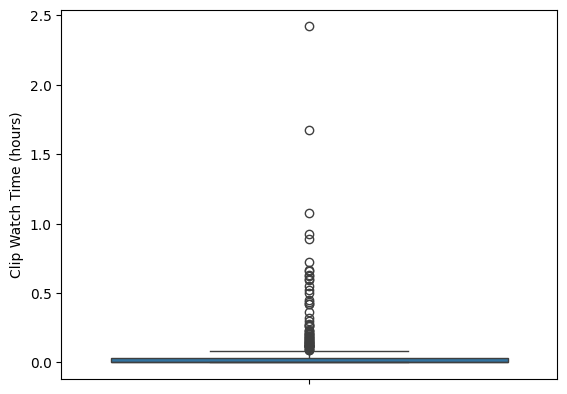

Estimated Revenue (USD)


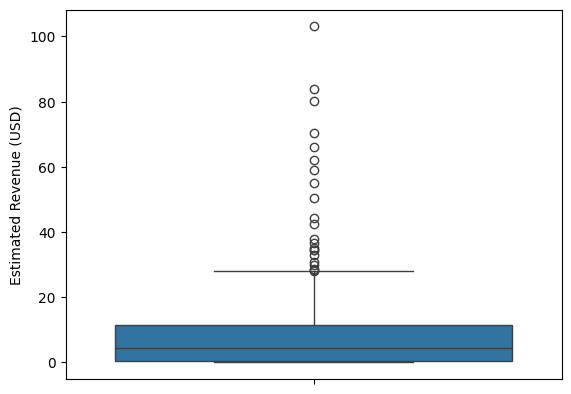

In [16]:
for i in df:
    print(i)
    sns.boxplot(df[i])
    plt.show()

In [20]:
continous_features = ['Watch Page Ads Revenue (USD)', 'YouTube Ads Revenue (USD)',
       'Estimated AdSense Revenue (USD)', 'Monetized Playbacks (Estimate)',
       'Ad Impressions', 'YouTube\xa0Premium (USD)',
       'YouTube Premium Watch Time (hours)', 'YouTube Premium Views',
       'Clip Views', 'Impressions', 'Watch Time (hours)', 'Likes',
       'Subscribers', 'New Subscribers', 'Clip Watch Time (hours)',
       'Estimated Revenue (USD)']
def outliers(df, drop = False):
    for each_feature in df.columns:
        feature_data = df[each_feature]
        Q1 = np.percentile(feature_data, 25.) # 25th percentile of the data of the given feature
        Q3 = np.percentile(feature_data, 75.) # 75th percentile of the data of the given feature
        IQR = Q3-Q1 #Interquartile Range
        outlier_step = IQR * 1.5 #That's we were talking about above
        outliers = feature_data[~((feature_data >= Q1 - outlier_step) & (feature_data <= Q3 + outlier_step))].index.tolist()
        if not drop:
            print('For the feature {}, No of Outliers is {}'.format(each_feature, len(outliers)))
        if drop:
            df.drop(outliers, inplace = True, errors = 'ignore')
            print('Outliers from {} feature removed'.format(each_feature))

# Pass the original dataframe 'df', instead of a subset.
# All the columns in continous_features are in the original df
outliers(df, drop=False)

For the feature Watch Page Ads Revenue (USD), No of Outliers is 19
For the feature YouTube Ads Revenue (USD), No of Outliers is 19
For the feature Estimated AdSense Revenue (USD), No of Outliers is 26
For the feature Monetized Playbacks (Estimate), No of Outliers is 14
For the feature Ad Impressions, No of Outliers is 26
For the feature YouTube Premium (USD), No of Outliers is 22
For the feature YouTube Premium Watch Time (hours), No of Outliers is 12
For the feature YouTube Premium Views, No of Outliers is 9
For the feature Clip Views, No of Outliers is 53
For the feature Impressions, No of Outliers is 14
For the feature Watch Time (hours), No of Outliers is 13
For the feature Likes, No of Outliers is 4
For the feature Subscribers, No of Outliers is 23
For the feature New Subscribers, No of Outliers is 21
For the feature Clip Watch Time (hours), No of Outliers is 63
For the feature Estimated Revenue (USD), No of Outliers is 22


In [21]:
 outliers(df[continous_features],drop=True)

Outliers from Watch Page Ads Revenue (USD) feature removed
Outliers from YouTube Ads Revenue (USD) feature removed
Outliers from Estimated AdSense Revenue (USD) feature removed
Outliers from Monetized Playbacks (Estimate) feature removed
Outliers from Ad Impressions feature removed
Outliers from YouTube Premium (USD) feature removed
Outliers from YouTube Premium Watch Time (hours) feature removed
Outliers from YouTube Premium Views feature removed
Outliers from Clip Views feature removed
Outliers from Impressions feature removed
Outliers from Watch Time (hours) feature removed
Outliers from Likes feature removed
Outliers from Subscribers feature removed
Outliers from New Subscribers feature removed
Outliers from Clip Watch Time (hours) feature removed
Outliers from Estimated Revenue (USD) feature removed


<ipython-input-36-77d63b30edd5>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


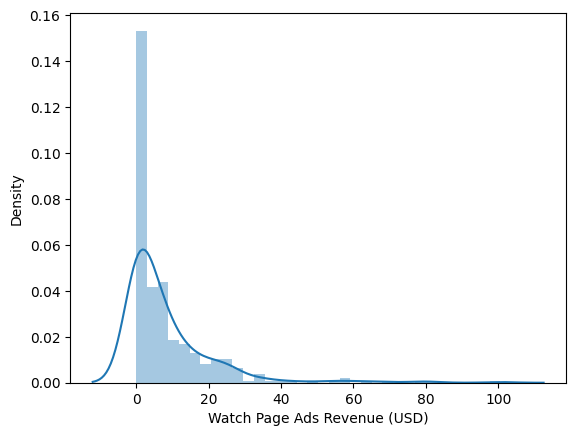

<ipython-input-36-77d63b30edd5>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


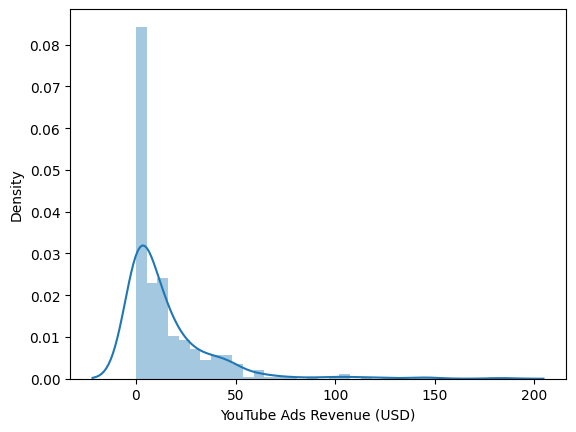

<ipython-input-36-77d63b30edd5>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


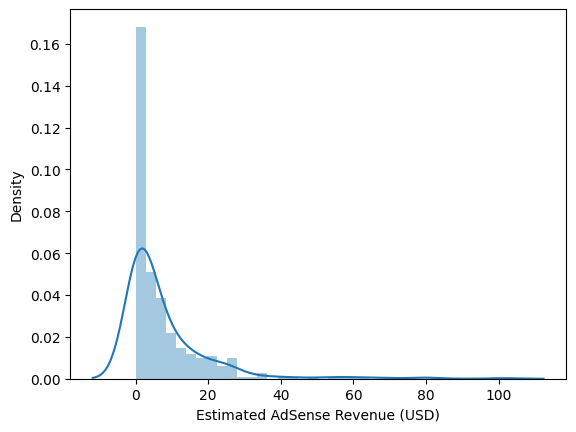

<ipython-input-36-77d63b30edd5>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


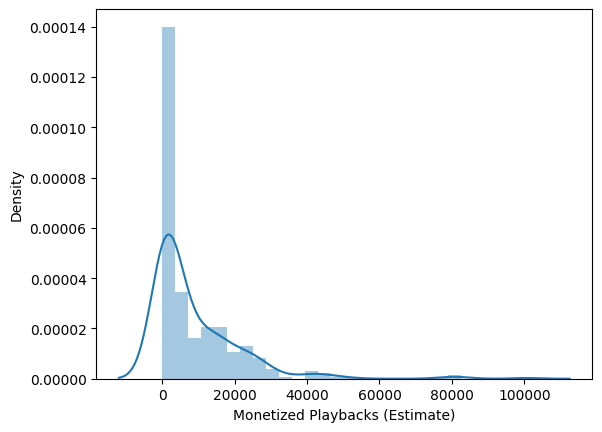

<ipython-input-36-77d63b30edd5>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


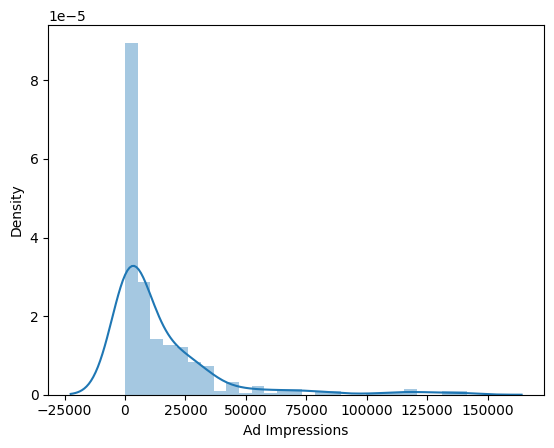

<ipython-input-36-77d63b30edd5>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


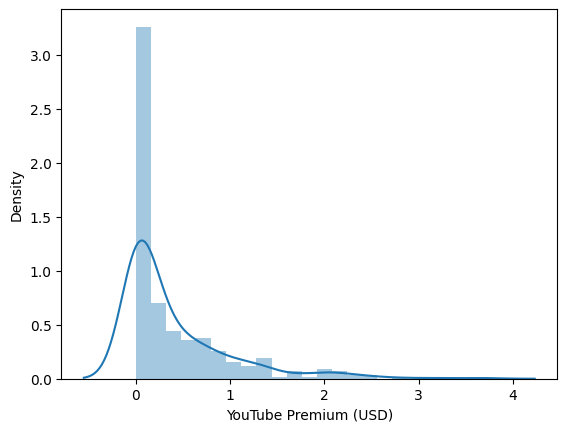

<ipython-input-36-77d63b30edd5>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


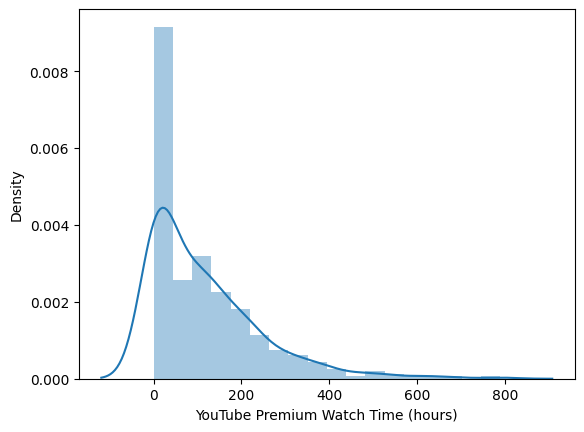

<ipython-input-36-77d63b30edd5>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


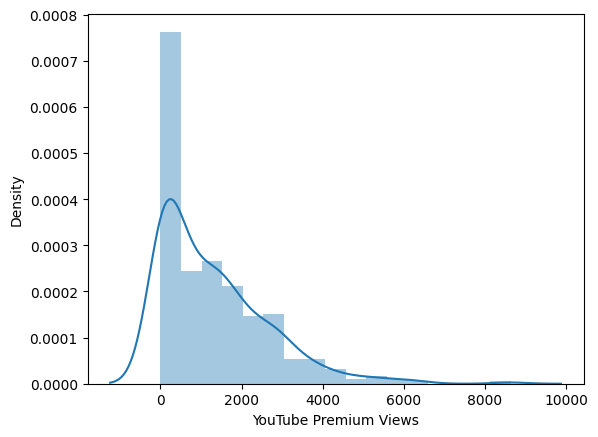

<ipython-input-36-77d63b30edd5>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


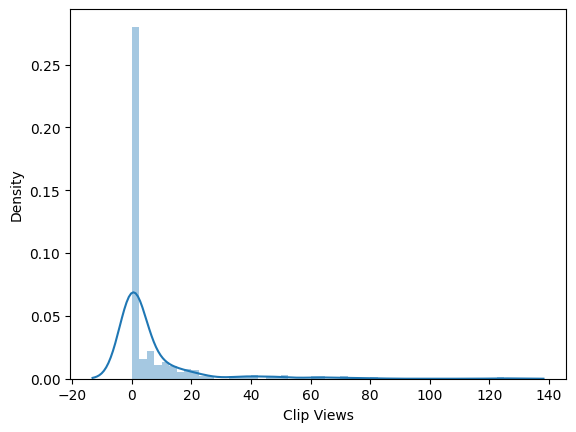

<ipython-input-36-77d63b30edd5>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


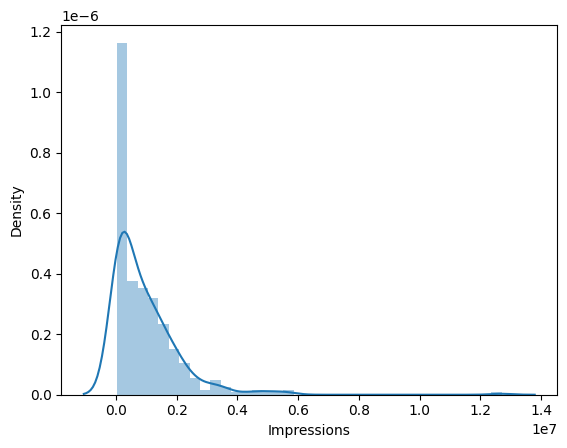

<ipython-input-36-77d63b30edd5>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


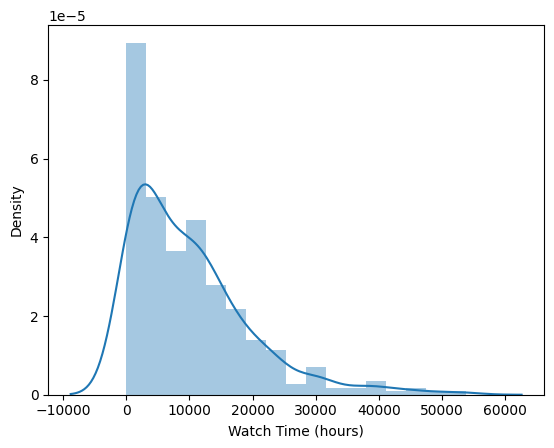

<ipython-input-36-77d63b30edd5>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


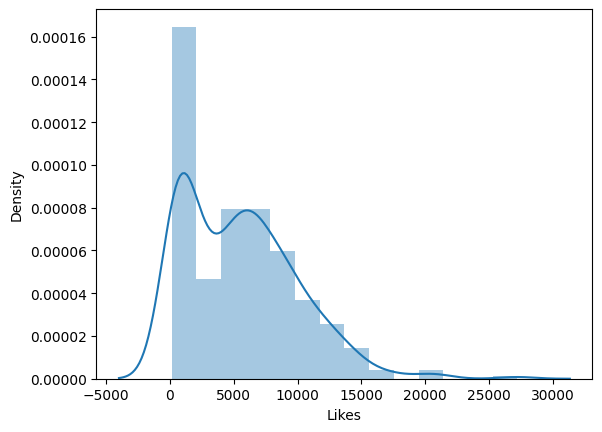

<ipython-input-36-77d63b30edd5>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


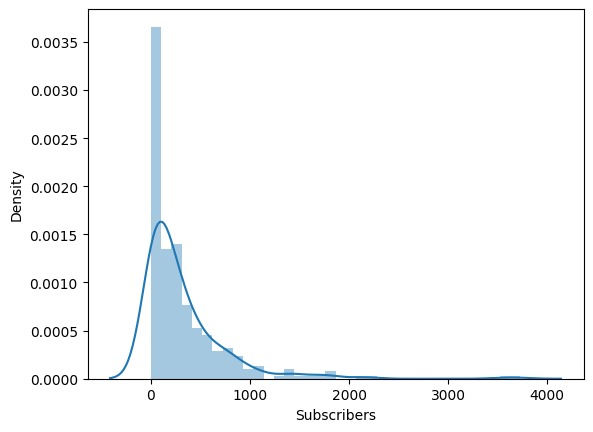

<ipython-input-36-77d63b30edd5>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


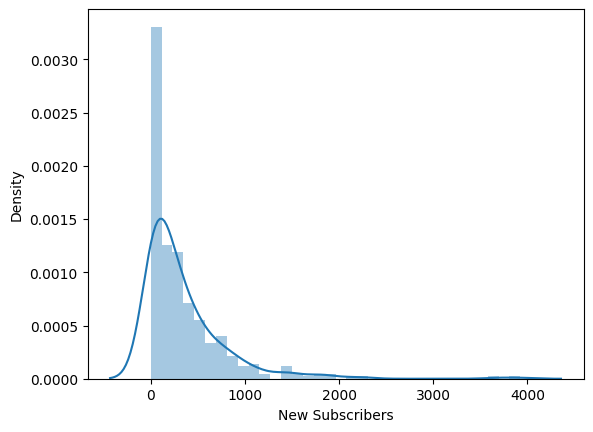

<ipython-input-36-77d63b30edd5>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


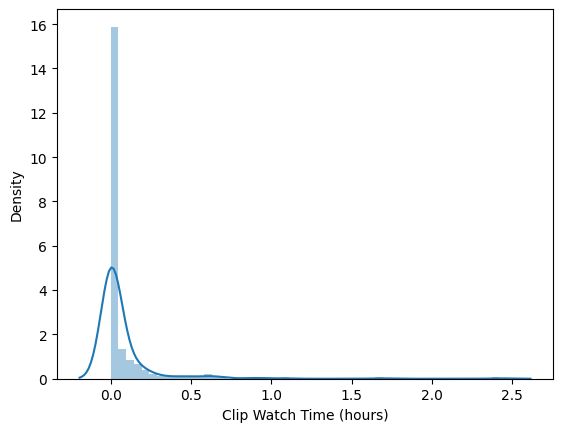

In [36]:
for i in df:
  sns.distplot(df[i])
  plt.show()




In [27]:
columns_to_transform = ['Watch Page Ads Revenue (USD)', 'YouTube Ads Revenue (USD)',
       'Estimated AdSense Revenue (USD)', 'Monetized Playbacks (Estimate)',
       'Ad Impressions', 'YouTube\xa0Premium (USD)',
       'YouTube Premium Watch Time (hours)', 'YouTube Premium Views',
       'Clip Views', 'Impressions', 'Watch Time (hours)', 'Likes',
       'Subscribers', 'New Subscribers', 'Clip Watch Time (hours)',
       'Estimated Revenue (USD)']

# Applying log transformation (log1p to handle zero values)
df_log_transformed = df.copy()
for col in columns_to_transform:
    df_log_transformed[col] = np.log1p(df[col])  # log1p(x) = log(x + 1)

# Display original and transformed data
print("Original Data:\n", df)
print("\nLog Transformed Data:\n", df_log_transformed)

Original Data:
      Watch Page Ads Revenue (USD)  YouTube Ads Revenue (USD)  \
0                           0.551                      1.002   
1                           0.645                      1.172   
2                           0.088                      0.160   
3                           0.016                      0.030   
4                           0.000                      0.000   
..                            ...                        ...   
359                         7.810                     14.199   
360                         8.477                     15.413   
361                         9.425                     17.136   
362                         3.729                      6.773   
363                         5.734                     10.412   

     Estimated AdSense Revenue (USD)  Monetized Playbacks (Estimate)  \
0                              0.527                           723.0   
1                              0.635                           727.0   

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [28]:
df.head()

,Watch Page Ads Revenue (USD),YouTube Ads Revenue (USD),Estimated AdSense Revenue (USD),Monetized Playbacks (Estimate),Ad Impressions,YouTube Premium (USD),YouTube Premium Watch Time (hours),YouTube Premium Views,Clip Views,Impressions,Watch Time (hours),Likes,Subscribers,New Subscribers,Clip Watch Time (hours),Estimated Revenue (USD)
0,0.551,1.002,0.527,723.0,981.0,0.010,2.5358,152.0,10.0,41118.0,533.1636,924.0,51.0,54.0,0.1575,0.561
1,0.645,1.172,0.635,727.0,861.0,0.004,0.8911,32.0,0.0,41627.0,500.5628,322.0,33.0,34.0,0.0000,0.648
2,0.088,0.160,0.088,76.0,88.0,0.001,0.1838,28.0,0.0,38713.0,70.7287,239.0,8.0,8.0,0.0000,0.089
3,0.016,0.030,0.016,18.0,35.0,0.000,0.0711,20.0,0.0,35245.0,17.6251,220.0,2.0,2.0,0.0000,0.017
4,0.000,0.000,0.000,0.0,0.0,0.000,0.2519,39.0,0.0,46218.0,104.3341,602.0,28.0,31.0,0.0000,0.000


In [30]:
target = df['Estimated Revenue (USD)']
target

,Estimated Revenue (USD)
0,0.561
1,0.648
2,0.089
3,0.017
4,0.000
...,...
359,8.063
360,8.705
361,9.852
362,3.858


In [31]:
df.drop('Estimated Revenue (USD)',axis=1,inplace=True)

<ipython-input-31-38e5a4c1c4a8>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop('Estimated Revenue (USD)',axis=1,inplace=True)


In [32]:
df.head()

,Watch Page Ads Revenue (USD),YouTube Ads Revenue (USD),Estimated AdSense Revenue (USD),Monetized Playbacks (Estimate),Ad Impressions,YouTube Premium (USD),YouTube Premium Watch Time (hours),YouTube Premium Views,Clip Views,Impressions,Watch Time (hours),Likes,Subscribers,New Subscribers,Clip Watch Time (hours)
0,0.551,1.002,0.527,723.0,981.0,0.010,2.5358,152.0,10.0,41118.0,533.1636,924.0,51.0,54.0,0.1575
1,0.645,1.172,0.635,727.0,861.0,0.004,0.8911,32.0,0.0,41627.0,500.5628,322.0,33.0,34.0,0.0000
2,0.088,0.160,0.088,76.0,88.0,0.001,0.1838,28.0,0.0,38713.0,70.7287,239.0,8.0,8.0,0.0000
3,0.016,0.030,0.016,18.0,35.0,0.000,0.0711,20.0,0.0,35245.0,17.6251,220.0,2.0,2.0,0.0000
4,0.000,0.000,0.000,0.0,0.0,0.000,0.2519,39.0,0.0,46218.0,104.3341,602.0,28.0,31.0,0.0000


Linear Regression

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

In [35]:
X_train, X_test, y_train, y_test = train_test_split(df, target, test_size=0.2, random_state=42)

# Step 3: Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4: Train the linear regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Step 5: Predict on test data
y_pred = model.predict(X_test_scaled)

# Step 6: Evaluate model accuracy (R² Score)
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.2f}")

R² Score: 1.00
